[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/LeinMS/hse-image-captioning/blob/main/src/eval_fine_tuned/sft/analysis/qwen3_VL_2b_sft_trl_analysis.ipynb)


#1. Import modules and load dataset

In [ ]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from datasets import load_dataset

dataset = load_dataset("leinms/flickr30k-qwen3-vl-2b-sft-trl-with-judge")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/881 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/40.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'alt_text', 'sentids', 'split', 'img_id', 'filename', 'original_alt_text', 'objects', 'baseline_answ', 'semantic_similarity', 'object_coverage', 'hallucination_score', 'completeness', 'instruction_following', 'fluency', 'final_score'],
        num_rows: 1000
    })
})

In [ ]:
import pandas as pd
df = dataset['train'].to_pandas()

In [ ]:
df.head(3)

,image,alt_text,sentids,split,img_id,filename,original_alt_text,objects,baseline_answ,semantic_similarity,object_coverage,hallucination_score,completeness,instruction_following,fluency,final_score
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,Person wearing a colorful hat and glasses.,"[125, 126, 127, 128, 129]",test,25,1007129816.jpg,[The man with pierced ears is wearing glasses ...,"[person, hat, glasses]",A person wearing a colorful hat and glasses.,10,10,10,10,10,10,100
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,A dog running on green grass near a white fence.,"[170, 171, 172, 173, 174]",test,34,1009434119.jpg,[A black and white dog is running in a grassy ...,"[dog, green grass, white fence, trees, buildings]",A dog running on a grassy field near a fence.,9,10,10,9,10,10,96
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,A child and a person practicing martial arts o...,"[255, 256, 257, 258, 259]",test,51,101362133.jpg,[A young female student performing a downward ...,"[child, person, martial arts, mats, uniforms]",Two people practicing martial arts on a mat.,8,10,10,8,10,10,90


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   image                  1000 non-null   object
 1   alt_text               1000 non-null   object
 2   sentids                1000 non-null   object
 3   split                  1000 non-null   object
 4   img_id                 1000 non-null   object
 5   filename               1000 non-null   object
 6   original_alt_text      1000 non-null   object
 7   objects                1000 non-null   object
 8   baseline_answ          1000 non-null   object
 9   semantic_similarity    1000 non-null   int64 
 10  object_coverage        1000 non-null   int64 
 11  hallucination_score    1000 non-null   int64 
 12  completeness           1000 non-null   int64 
 13  instruction_following  1000 non-null   int64 
 14  fluency                1000 non-null   int64 
 15  final_score           

# 2. Base statistics

## 2. Base statistics

## Model Evaluation Metrics Summary (Fine-tuned)

This summary describes the performance metrics for the **fine-tuned Qwen3-VL-2b** model, based on the updated evaluation results.

### Detailed Metric Descriptions

- **Semantic Similarity (≈ 7.88/10):**  
  The model captures the overall meaning reliably and more consistently than the baseline. Remaining errors are mostly subtle: occasional shifts in the exact action, relations between subjects, or missed fine-grained context.

- **Object Coverage (≈ 8.74/10):**  
  Object recognition is very strong and slightly improved. The model typically identifies the main entities in the scene, with most misses happening in cluttered images or when small/secondary objects carry important context.

- **Hallucination Score (≈ 9.19/10):**  
  Hallucinations are now relatively rare. When they appear, they tend to be mild (extra attributes, minor actions, or over-specific details) rather than entirely invented objects, indicating significantly better visual grounding.

- **Completeness (≈ 8.02/10):**  
  Completeness is solid: the model usually describes the key elements of the scene and includes more relevant details than the baseline. The main weakness remains complex scenes with multiple salient actors where some important interaction or context can be omitted.

- **Instruction Following (≈ 8.97/10):**  
  Instruction adherence is strong. Captions are generally better aligned with expected format and length, with fewer unnecessary additions or subjective phrasing compared to the baseline.

- **Fluency (≈ 9.59/10):**  
  Language quality is excellent and near-native. Errors are driven primarily by visual understanding limits rather than grammatical or stylistic issues.

- **Final Score (≈ 85.98/100):**  
  A final score around 86 indicates a clear improvement over the baseline and a robust, high-quality captioning model. The system is especially strong in factual grounding (hallucination control), instruction compliance, and maintaining fluent, readable captions, while still having headroom in nuanced semantics and dense multi-subject scenes.

---

## Conclusion

The fine-tuned model represents a meaningful upgrade over the baseline: it is more reliable in semantic alignment, notably better at avoiding hallucinations, and substantially improved in instruction following, while maintaining excellent fluency and strong object coverage. Remaining opportunities are concentrated in fine-grained relational understanding and completeness in complex multi-actor scenes.


In [ ]:
df.describe()

,semantic_similarity,object_coverage,hallucination_score,completeness,instruction_following,fluency,final_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,7.877000,8.740000,9.191000,8.022000,8.966000,9.591000,85.984000
std,1.701401,1.441693,1.204147,1.662612,1.283156,0.663445,13.122879
min,1.000000,2.000000,2.000000,2.000000,3.000000,5.000000,20.000000
25%,7.000000,8.000000,8.000000,7.000000,9.000000,9.000000,80.000000
50%,8.000000,9.000000,10.000000,8.000000,9.000000,10.000000,88.000000
75%,9.000000,10.000000,10.000000,9.000000,10.000000,10.000000,96.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,100.000000


## 2.1 Only mean values

In [ ]:
metric_cols = [
    "semantic_similarity",
    "object_coverage",
    "hallucination_score",
    "completeness",
    "instruction_following",
    "fluency",
    "final_score",
]

print("\n=== Mean values of metrics ===")
print(df[metric_cols].mean())


=== Mean values of metrics ===
semantic_similarity       7.877
object_coverage           8.740
hallucination_score       9.191
completeness              8.022
instruction_following     8.966
fluency                   9.591
final_score              85.984
dtype: float64


# 3. Histograms

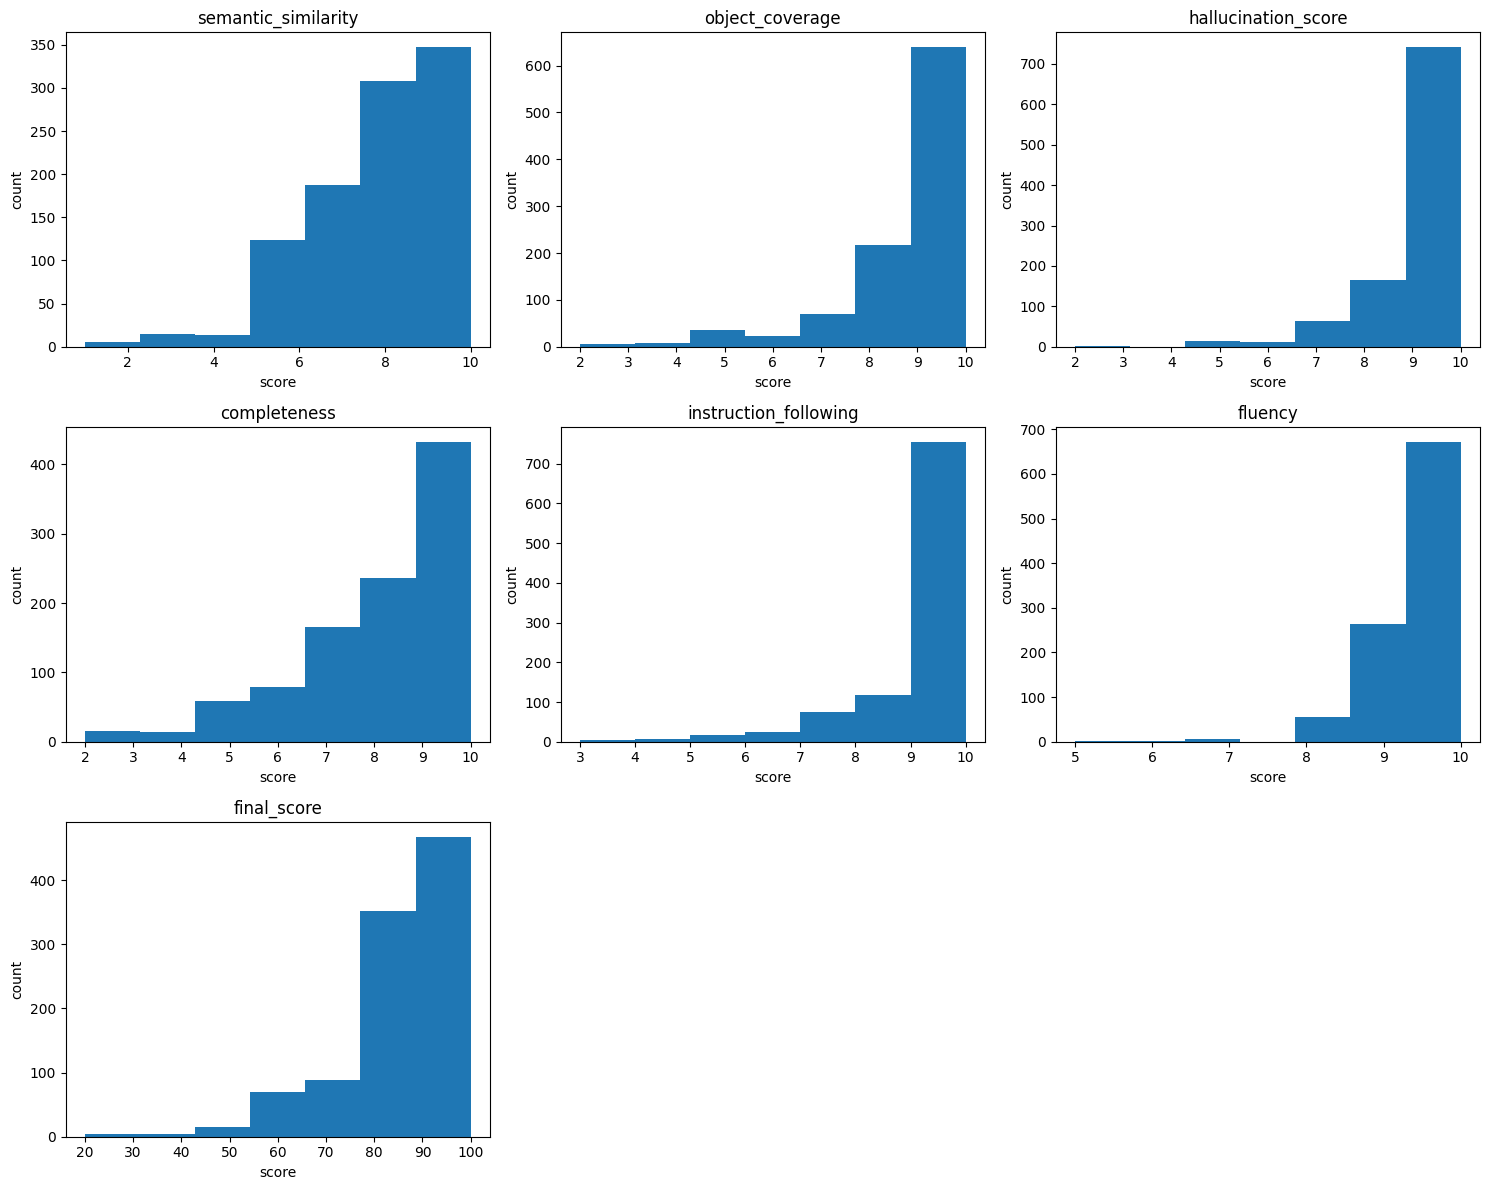

In [ ]:
def plot_histograms(df, cols, bins=7):
    n_cols = 3
    n_rows = int(np.ceil(len(cols) / n_cols))
    plt.figure(figsize=(5 * n_cols, 4 * n_rows))

    for i, col in enumerate(cols, 1):
        plt.subplot(n_rows, n_cols, i)
        plt.hist(df[col], bins=bins)
        plt.title(col)
        plt.xlabel("score")
        plt.ylabel("count")

    plt.tight_layout()
    plt.show()

plot_histograms(df, metric_cols)

# 4. Heatmap


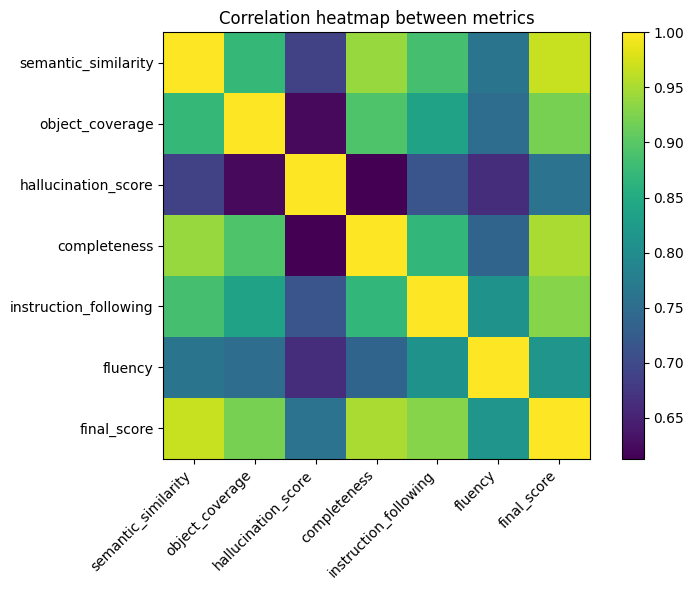

In [ ]:
corr = df[metric_cols].corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr, interpolation="nearest")
plt.xticks(range(len(metric_cols)), metric_cols, rotation=45, ha="right")
plt.yticks(range(len(metric_cols)), metric_cols)
plt.colorbar()
plt.title("Correlation heatmap between metrics")
plt.tight_layout()
plt.show()

# 5. Top-K / Bottom-K examples by metrics

In [ ]:
from PIL import Image
from io import BytesIO

def get_image_from_bytes(image_data): # Переименуем для ясности
    """Возвращает объект PIL.Image из словаря байтов."""
    if not isinstance(image_data, dict) or 'bytes' not in image_data:
        return None
    try:
        image_stream = BytesIO(image_data['bytes'])
        img = Image.open(image_stream)
        return img # <--- КЛЮЧ: Возвращаем объект Image
    except Exception:
        return None

In [ ]:
def show_examples(df, sort_by, ascending=True, k=5):
    """
    Печатает top-K или bottom-K примеров по указанной метрике.
    ascending=True  → самые низкие значения
    ascending=False → самые высокие
    """
    subset = df.sort_values(by=sort_by, ascending=ascending).head(k)
    direction = "LOWEST" if ascending else "HIGHEST"
    print(f"\n=== {direction} {k} examples by {sort_by} ===\n")

    cols_to_show = [
        "alt_text",
        "baseline_answ",
        "semantic_similarity",
        "object_coverage",
        "hallucination_score",
        "completeness",
        "instruction_following",
        "fluency",
        "final_score",
    ]

    for idx, row in subset.iterrows():
        print(f"[index={idx}]")
        # print(row["image"])
        img = get_image_from_bytes(row["image"])
        display(img)
        print("GOLD :", row["alt_text"])
        print("MODEL:", row["baseline_answ"])
        for c in cols_to_show[2:]:
            print(f"  {c}: {row[c]}")
        print("-" * 80)
        # break

##5.1 The worst 3 results in the final score


=== LOWEST 3 examples by final_score ===

[index=71]


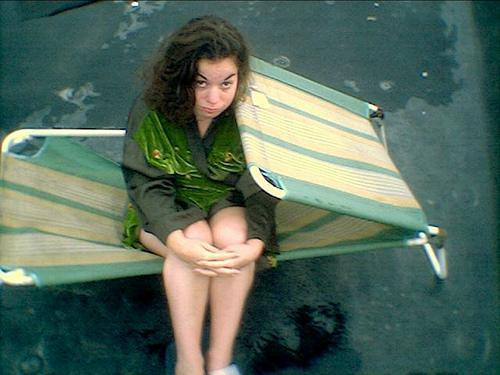

GOLD : Child sitting on a broken outdoor chair.
MODEL: A person sitting on a bench in a pool.
  semantic_similarity: 2
  object_coverage: 2
  hallucination_score: 2
  completeness: 2
  instruction_following: 3
  fluency: 5
  final_score: 20
--------------------------------------------------------------------------------
[index=941]


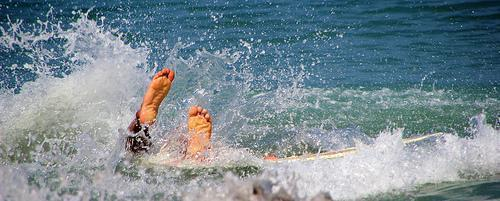

GOLD : Feet sticking out of the water at the beach.
MODEL: A person surfing on a wave with splashing water.
  semantic_similarity: 1
  object_coverage: 2
  hallucination_score: 5
  completeness: 2
  instruction_following: 3
  fluency: 8
  final_score: 21
--------------------------------------------------------------------------------
[index=384]


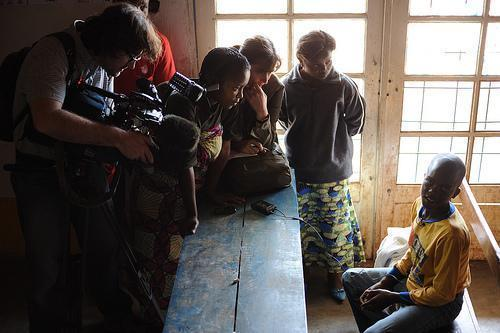

GOLD : People talking to a person sitting on a bench.
MODEL: People sitting and standing in a room with a camera.
  semantic_similarity: 2
  object_coverage: 3
  hallucination_score: 5
  completeness: 3
  instruction_following: 3
  fluency: 6
  final_score: 25
--------------------------------------------------------------------------------


In [ ]:
show_examples(df, "final_score", ascending=True, k=3)

##5.2 The best 3 results in the final score


=== HIGHEST 3 examples by final_score ===

[index=999]


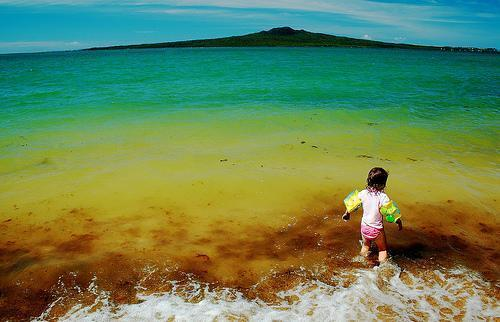

GOLD : A child playing in shallow water at the beach.
MODEL: A child playing in the shallow water at the beach.
  semantic_similarity: 10
  object_coverage: 10
  hallucination_score: 10
  completeness: 10
  instruction_following: 10
  fluency: 10
  final_score: 100
--------------------------------------------------------------------------------
[index=0]


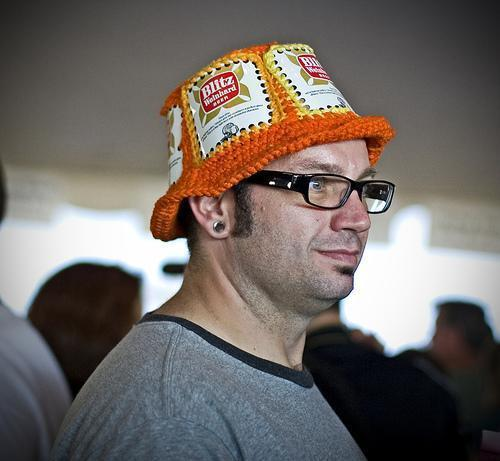

GOLD : Person wearing a colorful hat and glasses.
MODEL: A person wearing a colorful hat and glasses.
  semantic_similarity: 10
  object_coverage: 10
  hallucination_score: 10
  completeness: 10
  instruction_following: 10
  fluency: 10
  final_score: 100
--------------------------------------------------------------------------------
[index=994]


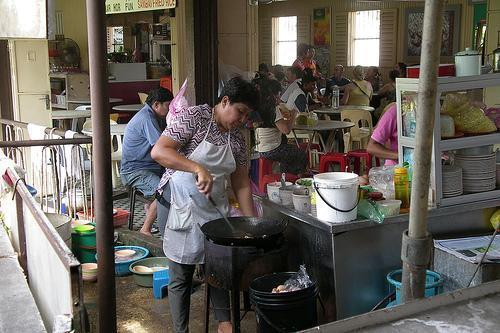

GOLD : Person cooking in a busy food stall.
MODEL: A person cooking in a busy food stall.
  semantic_similarity: 10
  object_coverage: 10
  hallucination_score: 10
  completeness: 10
  instruction_following: 10
  fluency: 10
  final_score: 100
--------------------------------------------------------------------------------


In [ ]:
show_examples(df, "final_score", ascending=False, k=3)

#6 Captions length analysis

In [ ]:
df["alt_len"] = df["alt_text"].astype(str).str.split().str.len()
df["baseline_len"] = df["baseline_answ"].astype(str).str.split().str.len()

print("\n=== Captions length staistics ===")
print(df[["alt_len", "baseline_len"]].describe())


=== Captions length staistics ===
          alt_len  baseline_len
count  1000.00000   1000.000000
mean      8.91300      9.023000
std       1.31269      1.340249
min       4.00000      6.000000
25%       8.00000      8.000000
50%       9.00000      9.000000
75%      10.00000     10.000000
max      13.00000     14.000000
